In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Car_Price_Prediction.csv")

In [3]:
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [5]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

In [6]:
df.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


In [7]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Size', 'Mileage', 'Fuel Type',
       'Transmission', 'Price'],
      dtype='object')

In [8]:
df.columns = df.columns.str.replace(" ","_")

In [9]:
df.head()

,Make,Model,Year,Engine_Size,Mileage,Fuel_Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [10]:
df["Make"].value_counts()

Make
Ford      225
Audi      212
Honda     198
Toyota    187
BMW       178
Name: count, dtype: int64

In [11]:
df["Model"].value_counts()

Model
Model B    212
Model C    205
Model A    202
Model D    197
Model E    184
Name: count, dtype: int64

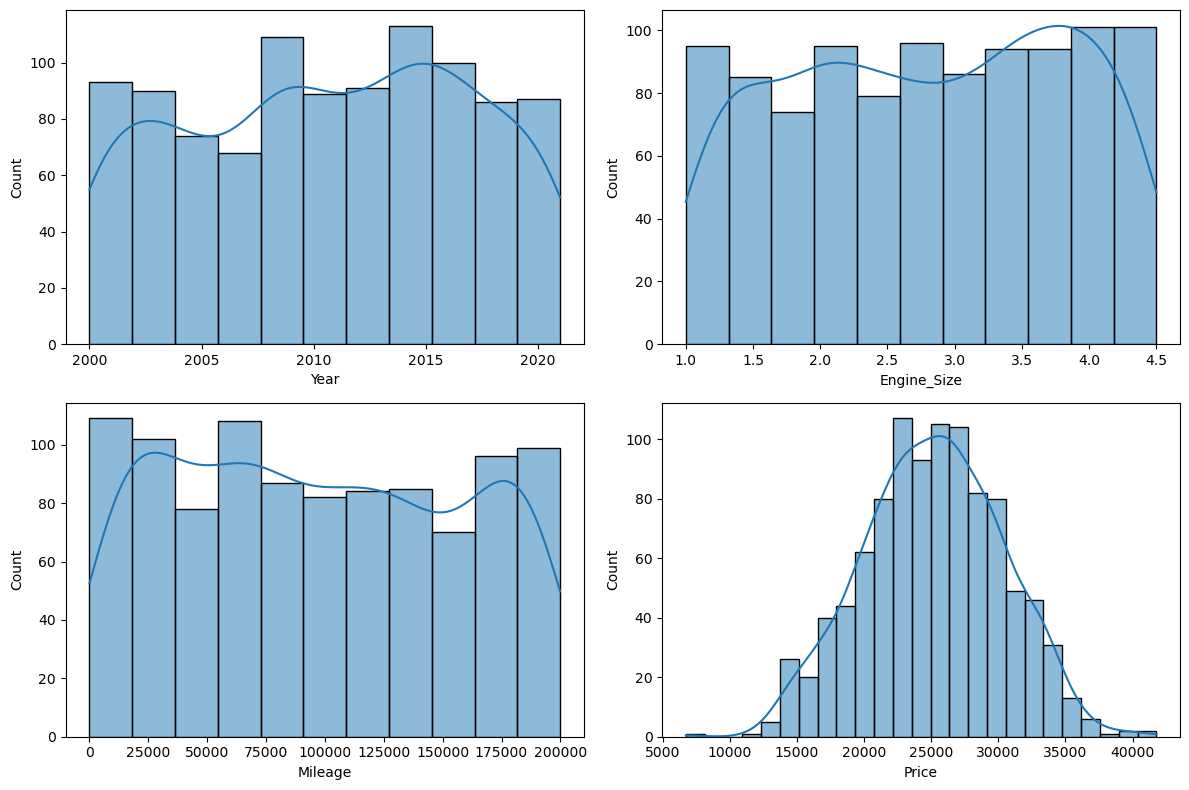

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df["Year"], kde=True, ax=axes[0, 0])
sns.histplot(df["Engine_Size"], kde=True, ax=axes[0, 1])
sns.histplot(df["Mileage"], kde=True, ax=axes[1, 0])
sns.histplot(df["Price"], kde=True, ax=axes[1, 1])

plt.tight_layout()
plt.show()

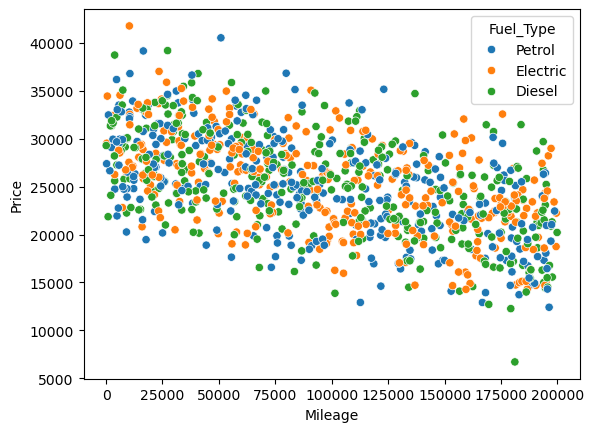

In [13]:
sns.scatterplot(data = df, x = "Mileage", y= "Price", hue = "Fuel_Type")
plt.show()

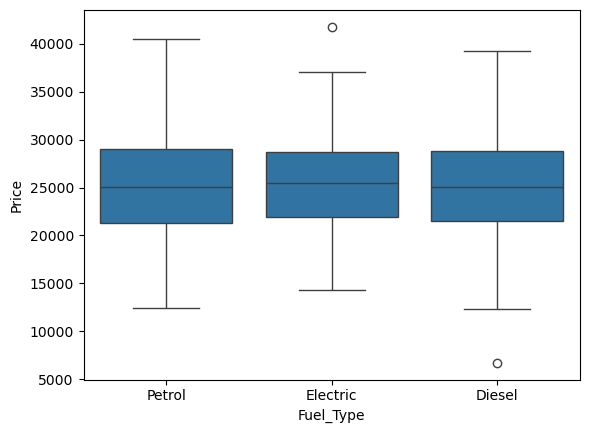

In [14]:
sns.boxplot(data = df, x = "Fuel_Type", y = "Price")
plt.show()

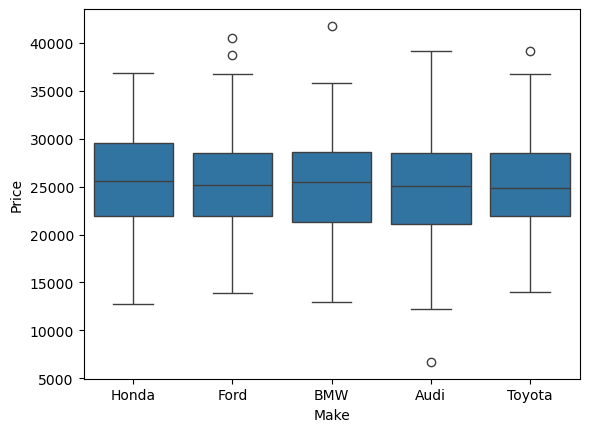

In [15]:
sns.boxplot(data = df, x = "Make", y = "Price")
plt.show()

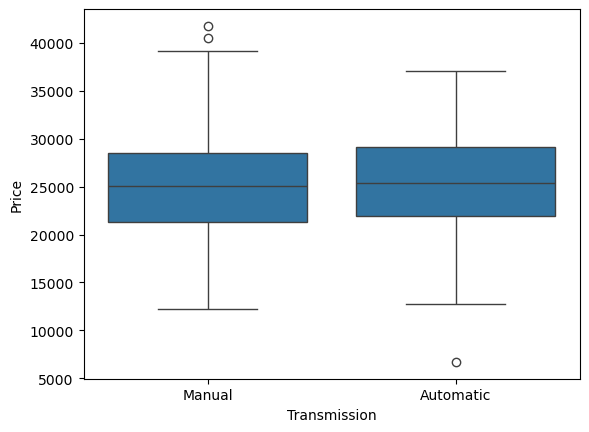

In [16]:
sns.boxplot(data = df, x = "Transmission", y = "Price")
plt.show()

<Axes: >

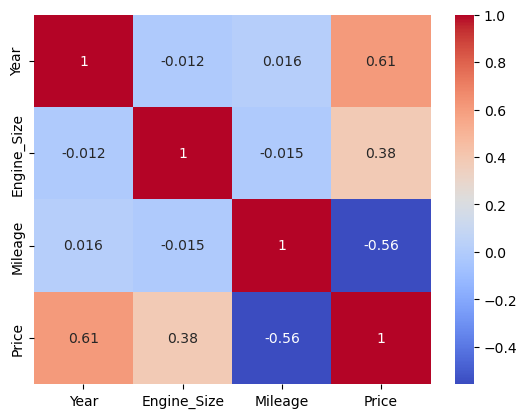

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

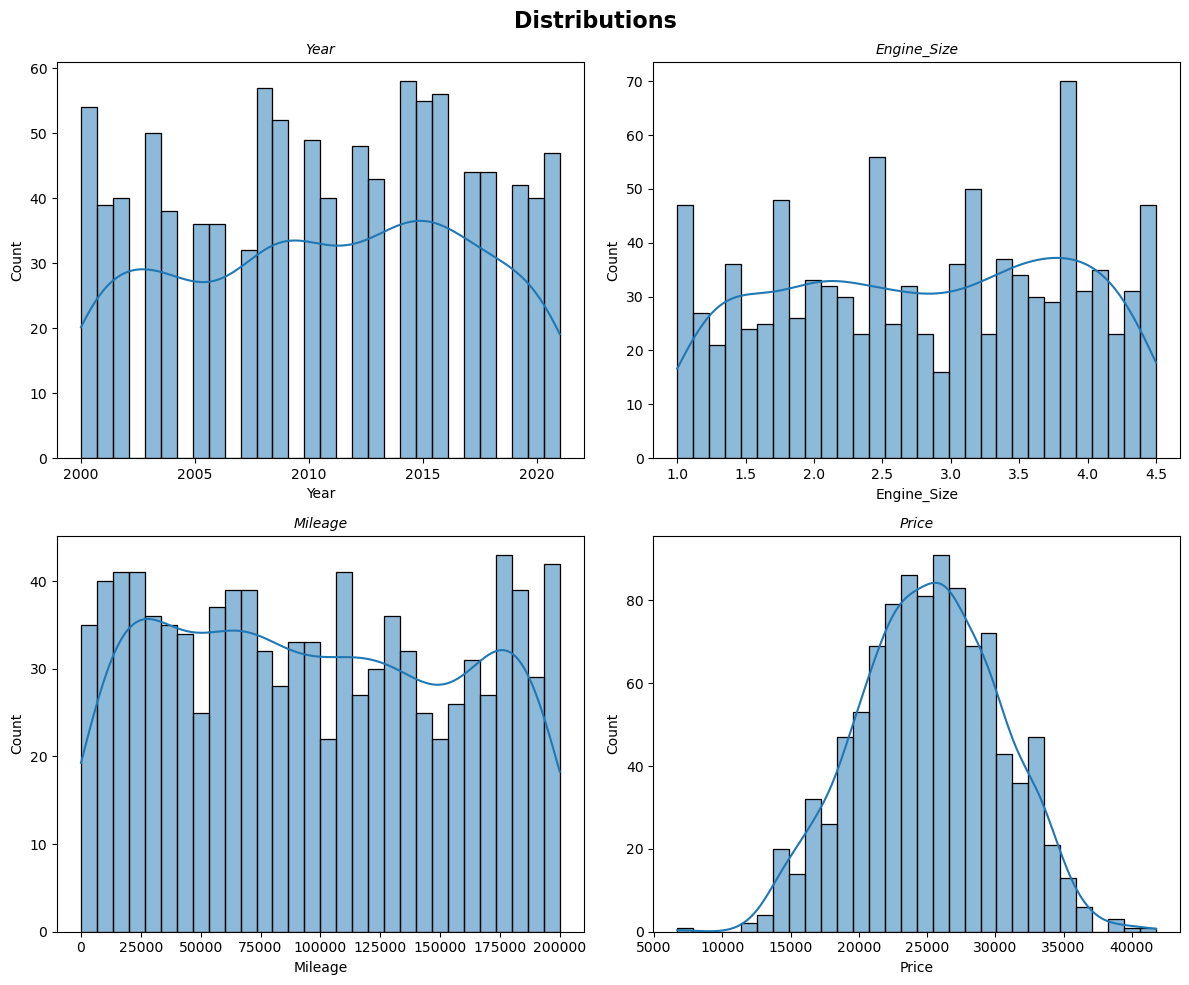

In [18]:
columns = ['Year', 'Engine_Size', 'Mileage', 'Price']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
fig.suptitle("Distributions", fontsize=16, fontweight="bold")

for i, col in enumerate(columns):
    row = i // 2  
    col_idx = i % 2 
    
    ax = axes[row, col_idx]
    sns.histplot(data=df, x=col, kde=True, ax=ax, bins=30)
    ax.set_title(col, fontsize=10, fontstyle="italic")

plt.tight_layout()
plt.show()

In [19]:
def find_outliers_iqr(df, threshold = 1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[ (df[col] < lower_bound) | (df[col] > upper_bound)]
        
        outlier_summary[col] = {
            "outlier_count" : outliers.shape[0],
            "outlier_percentage" : 100 * outliers.shape[0] / df.shape[0],
            "lower_bound" : lower_bound,
            "upper_bound" : upper_bound
        }
    return pd.DataFrame(outlier_summary)

In [20]:
find_outliers_iqr(df, threshold = 1.5)

,Year,Engine_Size,Mileage,Price
outlier_count,0.0,0.0,0.00,3.000000
outlier_percentage,0.0,0.0,0.00,0.300000
lower_bound,1988.5,-0.8,-111544.75,10760.142463
upper_bound,2032.5,6.4,305291.25,39634.104881


In [21]:
def remove_outliers_from_column(df,target_col, threshold = 1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    return df[ (df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [22]:
def remove_outliers_from_all_columns(df, threshold = 1.5):
    df_clean = df.copy()
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    return df_clean.copy()

In [23]:
print("original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df, "median_house_value")
print("only target column cleaning shape: ", df_target_clean.shape)
df_all_clean = remove_outliers_from_all_columns(df)
print("all columns cleaning shape: ", df_all_clean.shape)

original data shape:  (1000, 8)
only target column cleaning shape:  (997, 8)
all columns cleaning shape:  (997, 8)


In [24]:
df_all_clean["Year"].value_counts(ascending = False)

Year
2014    58
2008    57
2016    56
2015    55
2000    53
2009    52
2003    50
2010    49
2012    48
2021    47
2018    44
2017    44
2013    43
2019    41
2002    40
2011    40
2020    39
2001    39
2004    38
2006    36
2005    36
2007    32
Name: count, dtype: int64

In [25]:
df_all_clean["Make"].value_counts()

Make
Ford      224
Audi      211
Honda     198
Toyota    187
BMW       177
Name: count, dtype: int64

In [26]:
df_all_clean["Model"].value_counts()

Model
Model B    211
Model C    204
Model A    201
Model D    197
Model E    184
Name: count, dtype: int64

In [27]:
df_all_clean["Age"] = 2026 - df["Year"]

In [28]:
df_all_clean = df_all_clean.drop("Year",  axis = 1)

In [29]:
df_all_clean.head()

,Make,Model,Engine_Size,Mileage,Fuel_Type,Transmission,Price,Age
0,Honda,Model B,3.9,74176,Petrol,Manual,30246.207931,11
1,Ford,Model C,1.7,94799,Electric,Automatic,22785.747684,12
2,BMW,Model B,4.1,98385,Electric,Manual,25760.290347,20
3,Honda,Model B,2.6,88919,Electric,Automatic,25638.003491,11
4,Honda,Model C,3.4,138482,Petrol,Automatic,21021.386657,22


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings("ignore")

In [31]:
X = df_all_clean.drop("Price", axis = 1)
y = df_all_clean["Price"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 15, test_size= 0.2)

In [33]:
categorical_cols = ["Make","Model","Fuel_Type","Transmission"]
numerical_cols = ["Age", "Engine_Size", "Mileage"]

preprocessor = ColumnTransformer(transformers =  [
                                    ('num', StandardScaler(), numerical_cols),
                                    ('cat', OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)
                                ], remainder= "passthrough")

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

In [34]:
preprocessor.get_feature_names_out()

array(['num__Age', 'num__Engine_Size', 'num__Mileage', 'cat__Make_BMW',
       'cat__Make_Ford', 'cat__Make_Honda', 'cat__Make_Toyota',
       'cat__Model_Model B', 'cat__Model_Model C', 'cat__Model_Model D',
       'cat__Model_Model E', 'cat__Fuel_Type_Electric',
       'cat__Fuel_Type_Petrol', 'cat__Transmission_Manual'], dtype=object)

In [35]:
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [36]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [37]:
models = {
    "Linear Regression" : LinearRegression(),
    "Lasso" : Lasso(),
    "Ridge" : Ridge(),
    "K Neighbors Regressor" : KNeighborsRegressor(),
    "Decision Tree" : DecisionTreeRegressor(),
    "Random Forest Regressor" : RandomForestRegressor(),
    "Adaboost Regressor" : AdaBoostRegressor(),
    "Gradient Boost Regressor" : GradientBoostingRegressor(),
    "XGBoost Regressor" : XGBRegressor(),
    "LightGBM Regressor": LGBMRegressor()
}

In [38]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_preprocessed, y_train)

    y_train_pred = model.predict(X_train_preprocessed)
    y_test_pred = model.predict(X_test_preprocessed)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    print("Model performance for Training Set")
    print("Root Mean Squared Error: ", model_train_rmse)
    print("Mean Absolute Error: ", model_train_mae)
    print("R2 Score: ", model_train_r2)

    print("-----------------------------------")
    
    print("Model performance for Test Set")
    print("Root Mean Squared Error: ", model_test_rmse)
    print("Mean Absolute Error: ", model_test_mae)
    print("R2 Score: ", model_test_r2)

    print("-----------------------------------")
    print("\n")

Linear Regression
Model performance for Training Set
Root Mean Squared Error:  2061.7821563643056
Mean Absolute Error:  1633.0668020287653
R2 Score:  0.8400617726665742
-----------------------------------
Model performance for Test Set
Root Mean Squared Error:  1993.3081267784514
Mean Absolute Error:  1598.8939600700958
R2 Score:  0.8333156672676431
-----------------------------------


Lasso
Model performance for Training Set
Root Mean Squared Error:  2061.821416869307
Mean Absolute Error:  1632.8313001720983
R2 Score:  0.8400556815135011
-----------------------------------
Model performance for Test Set
Root Mean Squared Error:  1991.8545987271896
Mean Absolute Error:  1598.5342735294284
R2 Score:  0.8335586723647377
-----------------------------------


Ridge
Model performance for Training Set
Root Mean Squared Error:  2061.792145628583
Mean Absolute Error:  1632.9721779303889
R2 Score:  0.8400602228722992
-----------------------------------
Model performance for Test Set
Root Mean 

  File "C:\Users\omers\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\omers\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\omers\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\omers\anaconda3\Lib\subprocess.

In [39]:
from scipy.stats import boxcox
from scipy.special import inv_boxcox

In [40]:
y_train_boxcox, lambda_value = boxcox(y_train)

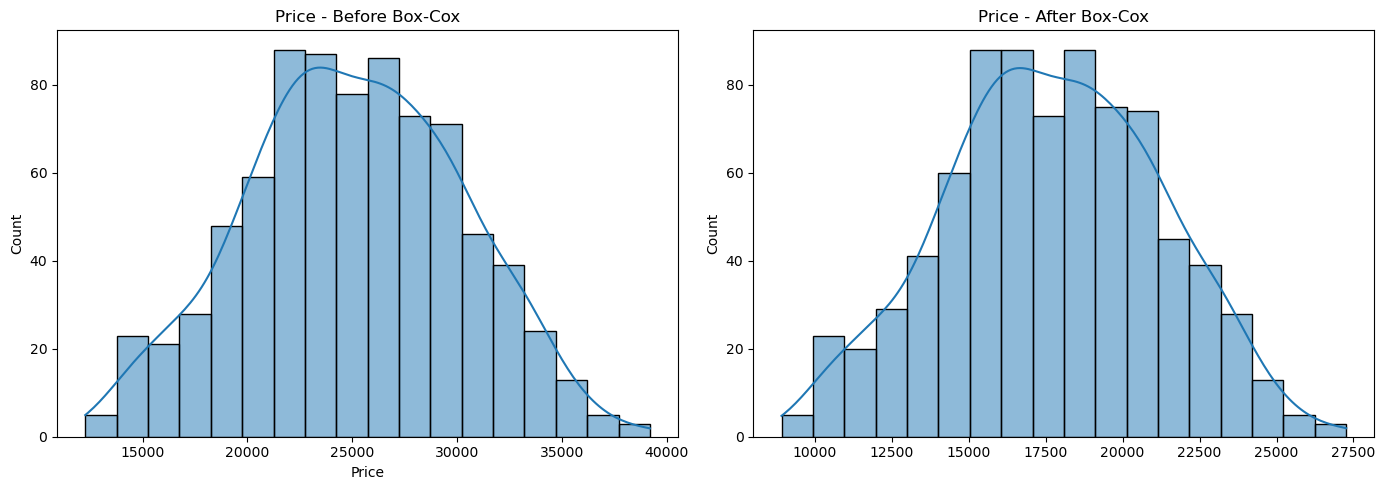

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title("Price - Before Box-Cox")

sns.histplot(y_train_boxcox, kde=True, ax=axes[1])
axes[1].set_title("Price - After Box-Cox")

plt.tight_layout()
plt.show()

In [42]:
boxcox_results = []

for name, model in models.items():

    model.fit(X_train_preprocessed, y_train_boxcox)

    y_train_pred_boxcox = model.predict(X_train_preprocessed)
    y_test_pred_boxcox = model.predict(X_test_preprocessed)

    y_train_pred = inv_boxcox(y_train_pred_boxcox, lambda_value)
    y_test_pred = inv_boxcox(y_test_pred_boxcox, lambda_value)

    train_mae, train_rmse, train_r2 = evaluate_model(
        y_train, 
        y_train_pred
    )

    test_mae, test_rmse, test_r2 = evaluate_model(
        y_test, 
        y_test_pred
    )

    boxcox_results.append({
        "Model": name,
        "Train MAE": train_mae,
        "Train RMSE": train_rmse,
        "Train R2": train_r2,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Test R2": test_r2
    })

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 337
[LightGBM] [Info] Number of data points in the train set: 797, number of used features: 14
[LightGBM] [Info] Start training from score 17713.546836
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

In [43]:
boxcox_results_df = pd.DataFrame(boxcox_results)

boxcox_results_df.sort_values(
    by="Test R2",
    ascending=False
)

,Model,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
1,Lasso,1.632393e+03,2.061360e+03,0.840127,1599.042294,1991.412209,0.833633
2,Ridge,1.632445e+03,2.061317e+03,0.840134,1598.262414,1992.160216,0.833508
0,Linear Regression,1.632537e+03,2.061308e+03,0.840135,1599.308559,1993.151796,0.833342
5,Random Forest Regressor,6.822746e+02,8.658501e+02,0.971793,1667.703122,2091.121231,0.816556
7,Gradient Boost Regressor,1.313740e+03,1.673358e+03,0.894648,1707.300969,2150.682504,0.805957
6,Adaboost Regressor,1.742757e+03,2.140710e+03,0.827582,1722.905533,2215.669675,0.794053
9,LightGBM Regressor,8.836377e+02,1.109971e+03,0.953646,1789.203697,2244.637191,0.788632
8,XGBoost Regressor,1.211920e+02,1.701942e+02,0.998910,1903.418352,2395.014287,0.759363
3,K Neighbors Regressor,1.755548e+03,2.198391e+03,0.818165,1957.120404,2513.024883,0.735065
4,Decision Tree,1.158265e-11,1.470530e-11,1.000000,2434.673803,3045.026070,0.611019


In [44]:
xgboost_params = {
        "learning_rate" : [0.1, 0.01],
        "max_depth" : [5,8,12,20,30],
        "n_estimators" : [100,200,300,500],
        "colsample_bytree" : [0.3, 0.4, 0.5, 0.7, 1]
}
from sklearn.model_selection import RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=XGBRegressor(), param_distributions=xgboost_params, cv = 5, n_jobs = -1)
randomized_cv.fit(X_train_preprocessed, y_train_boxcox)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.3, 0.4, 0.5, 0.7,
                                                             1],
                                        'learning_rate': [0.1, 0.01],
                                        'max_depth': [5, 8, 12, 20, 30],
                                        'n_estimators': [100, 200, 300, 500]})

In [45]:
randomized_cv.best_params_

{'n_estimators': 100,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 1}

In [55]:
xgb = XGBRegressor(n_estimators = 100, max_depth = 8, learning_rate = 0.1, colsample_bytree = 1)

In [56]:
xgb.fit(X_train_preprocessed, y_train_boxcox)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None, colsample_bytree=1,
             device=None, early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, ...)

In [70]:
y_train_pred_boxcox = xgb.predict(X_train_preprocessed)
y_test_pred_boxcox = xgb.predict(X_test_preprocessed)

y_train_pred_gercek = inv_boxcox(y_train_pred_boxcox, lambda_value)
y_test_pred_gercek = inv_boxcox(y_test_pred_boxcox, lambda_value)

model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred_gercek)
model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred_gercek)

print("XGBoost Regressor (Gerçek Fiyat Ölçeği)")
print("Model performance for Training Set")
print("Root Mean Squared Error: ", model_train_rmse)
print("Mean Absolute Error: ", model_train_mae)
print("R2 Score: ", model_train_r2)

print("--------------------------------------")

print("Model performance for Test Set")
print("Root Mean Squared Error: ", model_test_rmse)
print("Mean Absolute Error: ", model_test_mae)
print("R2 Score: ", model_test_r2)

print("--------------------------------------")

XGBoost Regressor (Gerçek Fiyat Ölçeği)
Model performance for Training Set
Root Mean Squared Error:  222.40058876896137
Mean Absolute Error:  159.3804086589617
R2 Score:  0.9981390333509894
--------------------------------------
Model performance for Test Set
Root Mean Squared Error:  2331.1945921454344
Mean Absolute Error:  1839.6418043801636
R2 Score:  0.772016739744686
--------------------------------------


In [59]:
ridge_params = {
    "alpha": [0.01, 0.1, 1.0, 10.0, 50.0, 100.0, 200.0],
    "solver": ["auto", "svd", "cholesky", "saga"]
}

In [60]:
lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 50.0],
    "max_iter": [1000, 5000, 10000],
    "selection": ["cyclic", "random"]
}

In [61]:
randomized_cv = RandomizedSearchCV(estimator=Ridge(), param_distributions=ridge_params, cv = 5, n_jobs = -1)
randomized_cv.fit(X_train_preprocessed, y_train_boxcox)

RandomizedSearchCV(cv=5, estimator=Ridge(), n_jobs=-1,
                   param_distributions={'alpha': [0.01, 0.1, 1.0, 10.0, 50.0,
                                                  100.0, 200.0],
                                        'solver': ['auto', 'svd', 'cholesky',
                                                   'saga']})

In [62]:
randomized_cv.best_params_

{'solver': 'saga', 'alpha': 10.0}

In [63]:
rdge = Ridge(solver = "saga", alpha = 10.0)

In [64]:
rdge.fit(X_train_preprocessed, y_train_boxcox)

Ridge(alpha=10.0, solver='saga')

In [73]:
y_train_pred_boxcox = rdge.predict(X_train_preprocessed)
y_test_pred_boxcox = rdge.predict(X_test_preprocessed)


y_train_pred_gercek = inv_boxcox(y_train_pred_boxcox, lambda_value)
y_test_pred_gercek = inv_boxcox(y_test_pred_boxcox, lambda_value)

model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred_gercek)
model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred_gercek)

print("Ridge")
print("Model performance for Training Set")
print("Root Mean Squared Error: ", model_train_rmse)
print("Mean Absolute Error: ", model_train_mae)
print("R2 Score: ", model_train_r2)

print("--------------------------------------")

print("Model performance for Test Set")
print("Root Mean Squared Error: ", model_test_rmse)
print("Mean Absolute Error: ", model_test_mae)
print("R2 Score: ", model_test_r2)

print("--------------------------------------")

Ridge
Model performance for Training Set
Root Mean Squared Error:  2062.253989600514
Mean Absolute Error:  1631.960236257005
R2 Score:  0.8399885614341962
--------------------------------------
Model performance for Test Set
Root Mean Squared Error:  1984.4262767403739
Mean Absolute Error:  1591.257998889116
R2 Score:  0.8347977932606306
--------------------------------------


In [66]:
randomized_cv = RandomizedSearchCV(estimator=Lasso(), param_distributions=lasso_params, cv = 5, n_jobs = -1)
randomized_cv.fit(X_train_preprocessed, y_train_boxcox)

RandomizedSearchCV(cv=5, estimator=Lasso(), n_jobs=-1,
                   param_distributions={'alpha': [0.001, 0.01, 0.1, 1.0, 10.0,
                                                  50.0],
                                        'max_iter': [1000, 5000, 10000],
                                        'selection': ['cyclic', 'random']})

In [67]:
randomized_cv.best_params_

{'selection': 'cyclic', 'max_iter': 10000, 'alpha': 50.0}

In [68]:
lasso = Lasso(selection = "cyclic", max_iter = 10000, alpha = 50.0)

In [69]:
lasso.fit(X_train_preprocessed, y_train_boxcox)

Lasso(alpha=50.0, max_iter=10000)

In [72]:
y_train_pred_boxcox = lasso.predict(X_train_preprocessed)
y_test_pred_boxcox = lasso.predict(X_test_preprocessed)

y_train_pred_gercek = inv_boxcox(y_train_pred_boxcox, lambda_value)
y_test_pred_gercek = inv_boxcox(y_test_pred_boxcox, lambda_value)

model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred_gercek)
model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred_gercek)

print("Lasso")
print("Model performance for Training Set")
print("Root Mean Squared Error: ", model_train_rmse)
print("Mean Absolute Error: ", model_train_mae)
print("R2 Score: ", model_train_r2)

print("--------------------------------------")

print("Model performance for Test Set")
print("Root Mean Squared Error: ", model_test_rmse)
print("Mean Absolute Error: ", model_test_mae)
print("R2 Score: ", model_test_r2)

print("--------------------------------------")

Lasso
Model performance for Training Set
Root Mean Squared Error:  2072.6372662833833
Mean Absolute Error:  1641.529585801012
R2 Score:  0.838373216611536
--------------------------------------
Model performance for Test Set
Root Mean Squared Error:  1974.393927003504
Mean Absolute Error:  1583.1063595620299
R2 Score:  0.8364639442206867
--------------------------------------
